In [7]:
import pandas as pd

Understand the data

In [8]:


# Read CSV file
df = pd.read_csv("covid_19.csv")

# Show first 5 rows
df.head()

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


In [9]:
print(f"Print the dimension of the dataframe: {df.shape}\n")
df.info()

Print the dimension of the dataframe: (238, 9)

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    str    
 1   continent   236 non-null    str    
 2   population  229 non-null    float64
 3   day         238 non-null    str    
 4   time        238 non-null    str    
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 16.9 KB


In [10]:
df['continent'].value_counts()

continent
Africa           59
Asia             51
Europe           49
North-America    40
Oceania          21
South-America    15
All               1
Name: count, dtype: int64

## Data preparation: Data Cleaning
At the pre-prepare data for analysis:

Inspect missing values and remove them from data
Replace and transform cell data
Change the data types of columns

## check missing value

In [11]:
df[df["continent"].isnull()]

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
6,MS-Zaandam,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,9,7.0,2.0,NaN


In [12]:
df.isnull().sum()

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64

## Handle missing values seperately in numerical and categorical columns

In [13]:
df = df.dropna(subset=['continent', 'population'])

In [14]:
df['Deaths'] = df['Deaths'].fillna(0)
df['Recovered'] = df['Recovered'].fillna(0)
df['Tests'] = df['Tests'].fillna(0)

## Strategy C: Advanced Imputation for Machine Learning

IterativeImputer (MICE): Estimates missing values by modeling each feature with missing values as a function of other features.

KNNImputer: Fills missing values based on the average of the "nearest neighbor" countries with similar population and case characteristics.

In [15]:
from pandas.core.window import expanding
from sklearn.impute import KNNImputer

# Select numeric features for ML
ml_features = ['population', 'Cases', 'Recovered', 'Deaths', 'Tests']

imputer = KNNImputer(n_neighbors=3)
df_imputed = pd.DataFrame(imputer.fit_transform(df[ml_features]), columns=ml_features)

In [16]:
df.isnull().sum()

country       0
continent     0
population    0
day           0
time          0
Cases         0
Recovered     0
Deaths        0
Tests         0
dtype: int64

## Check duplicates

In [17]:
print("Sum of duplicated value: ", df_imputed.duplicated().sum(), '\n')

Sum of duplicated value:  0 



In [18]:
df.head

<bound method NDFrame.head of               country      continent   population         day  \
0        Saint-Helena         Africa       6115.0  2024-06-30   
1    Falkland-Islands  South-America       3539.0  2024-06-30   
2          Montserrat  North-America       4965.0  2024-06-30   
4        Vatican-City         Europe        799.0  2024-06-30   
5      Western-Sahara         Africa     626161.0  2024-06-30   
..                ...            ...          ...         ...   
233         Argentina  South-America   46010234.0  2024-06-30   
234       Netherlands         Europe   17211447.0  2024-06-30   
235            Mexico  North-America  131562772.0  2024-06-30   
236              Iran           Asia   86022837.0  2024-06-30   
237         Indonesia           Asia  279134505.0  2024-06-30   

                          time     Cases  Recovered    Deaths        Tests  
0    2024-06-30T16:15:16+00:00      2166        2.0       0.0          0.0  
1    2024-06-30T16:15:16+00:00     

In [20]:
import matplotlib.pyplot as plt


C:\Users\User\AppData\Local\Temp\ipykernel_17192\2590270953.py:77: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\OneDrive\Desktop\AMS\Covidnew\covid_kernel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


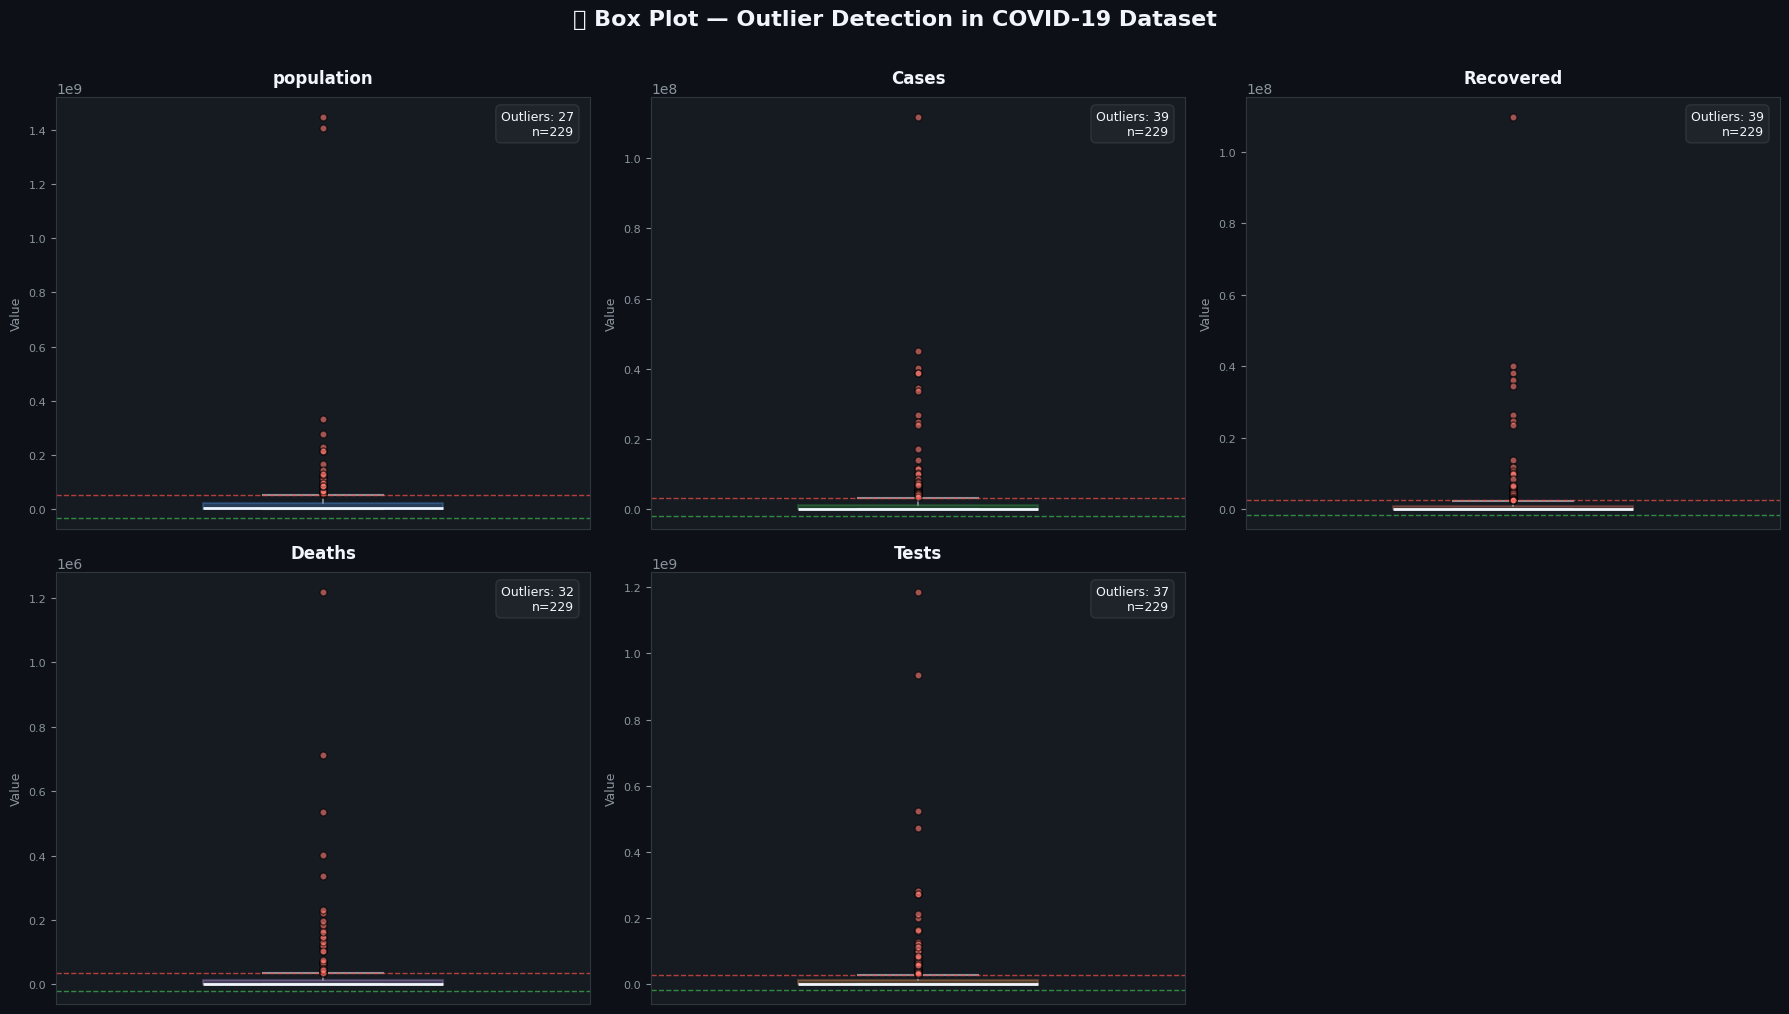


 Outlier Summary (IQR Method ±1.5×IQR):
Column           Outliers   Total       %
──────────────────────────────────────────
population             27     229   11.8%
Cases                  39     229   17.0%
Recovered              39     229   17.0%
Deaths                 32     229   14.0%
Tests                  37     229   16.2%


In [21]:
# ── Only columns that exist in the raw dataset ────────────────────────────────
numeric_cols = ['population', 'Cases', 'Recovered', 'Deaths', 'Tests']

# ── IQR-based outlier counter ─────────────────────────────────────────────────
def count_outliers(series):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return ((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum()

# ── Plot setup ────────────────────────────────────────────────────────────────
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, 5 * n_rows),
                         facecolor='#0d1117')
axes = axes.flatten()

colors = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657']

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.set_facecolor('#161b22')

    data = df[col].dropna()

    bp = ax.boxplot(data,
                    patch_artist=True,
                    vert=True,
                    widths=0.45,
                    showfliers=True,
                    flierprops=dict(marker='o', color='#ff7b72',
                                    markerfacecolor='#ff7b72',
                                    markersize=5, alpha=0.6, linestyle='none'),
                    medianprops=dict(color='#f0f6fc', linewidth=2),
                    whiskerprops=dict(color='#8b949e', linewidth=1.2),
                    capprops=dict(color='#8b949e', linewidth=1.5),
                    boxprops=dict(color=colors[i % len(colors)], linewidth=1.5))

    for patch in bp['boxes']:
        patch.set_facecolor(colors[i % len(colors)])
        patch.set_alpha(0.25)

    # IQR fence lines
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    lower_fence = Q1 - 1.5 * IQR
    n_outliers = count_outliers(df[col])

    ax.axhline(upper_fence, color='#f85149', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(lower_fence, color='#3fb950', linestyle='--', linewidth=1, alpha=0.7)

    ax.set_title(col, color='#f0f6fc', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Value', color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.xaxis.set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    ax.text(0.97, 0.97,
            f'Outliers: {n_outliers}\nn={len(data)}',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#f0f6fc',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#21262d',
                      edgecolor='#30363d', alpha=0.9))

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('📦 Box Plot — Outlier Detection in COVID-19 Dataset',
             color='#f0f6fc', fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n Outlier Summary (IQR Method ±1.5×IQR):")
print(f"{'Column':<15} {'Outliers':>9} {'Total':>7} {'%':>7}")
print("─" * 42)
for col in numeric_cols:
    data = df[col].dropna()
    n_out = count_outliers(df[col])
    pct = (n_out / len(data) * 100) if len(data) > 0 else 0
    print(f"{col:<15} {n_out:>9} {len(data):>7} {pct:>6.1f}%")


In [22]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col + '_capped'] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: {before} outliers capped → range [{lower:,.0f}, {upper:,.0f}]")
    return df

for col in ['Cases', 'Deaths', 'Recovered', 'Tests']:
    df = cap_outliers_iqr(df, col)


Cases: 39 outliers capped → range [-1,966,484, 3,350,364]
Deaths: 32 outliers capped → range [-21,206, 35,846]
Recovered: 39 outliers capped → range [-1,544,460, 2,581,308]
Tests: 37 outliers capped → range [-16,989,871, 28,932,345]


C:\Users\User\AppData\Local\Temp\ipykernel_17192\2746257672.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_17192\2746257672.py:79: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\OneDrive\Desktop\AMS\Covidnew\covid_kernel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\OneDrive\Desktop\AMS\Covidnew\covid_kernel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


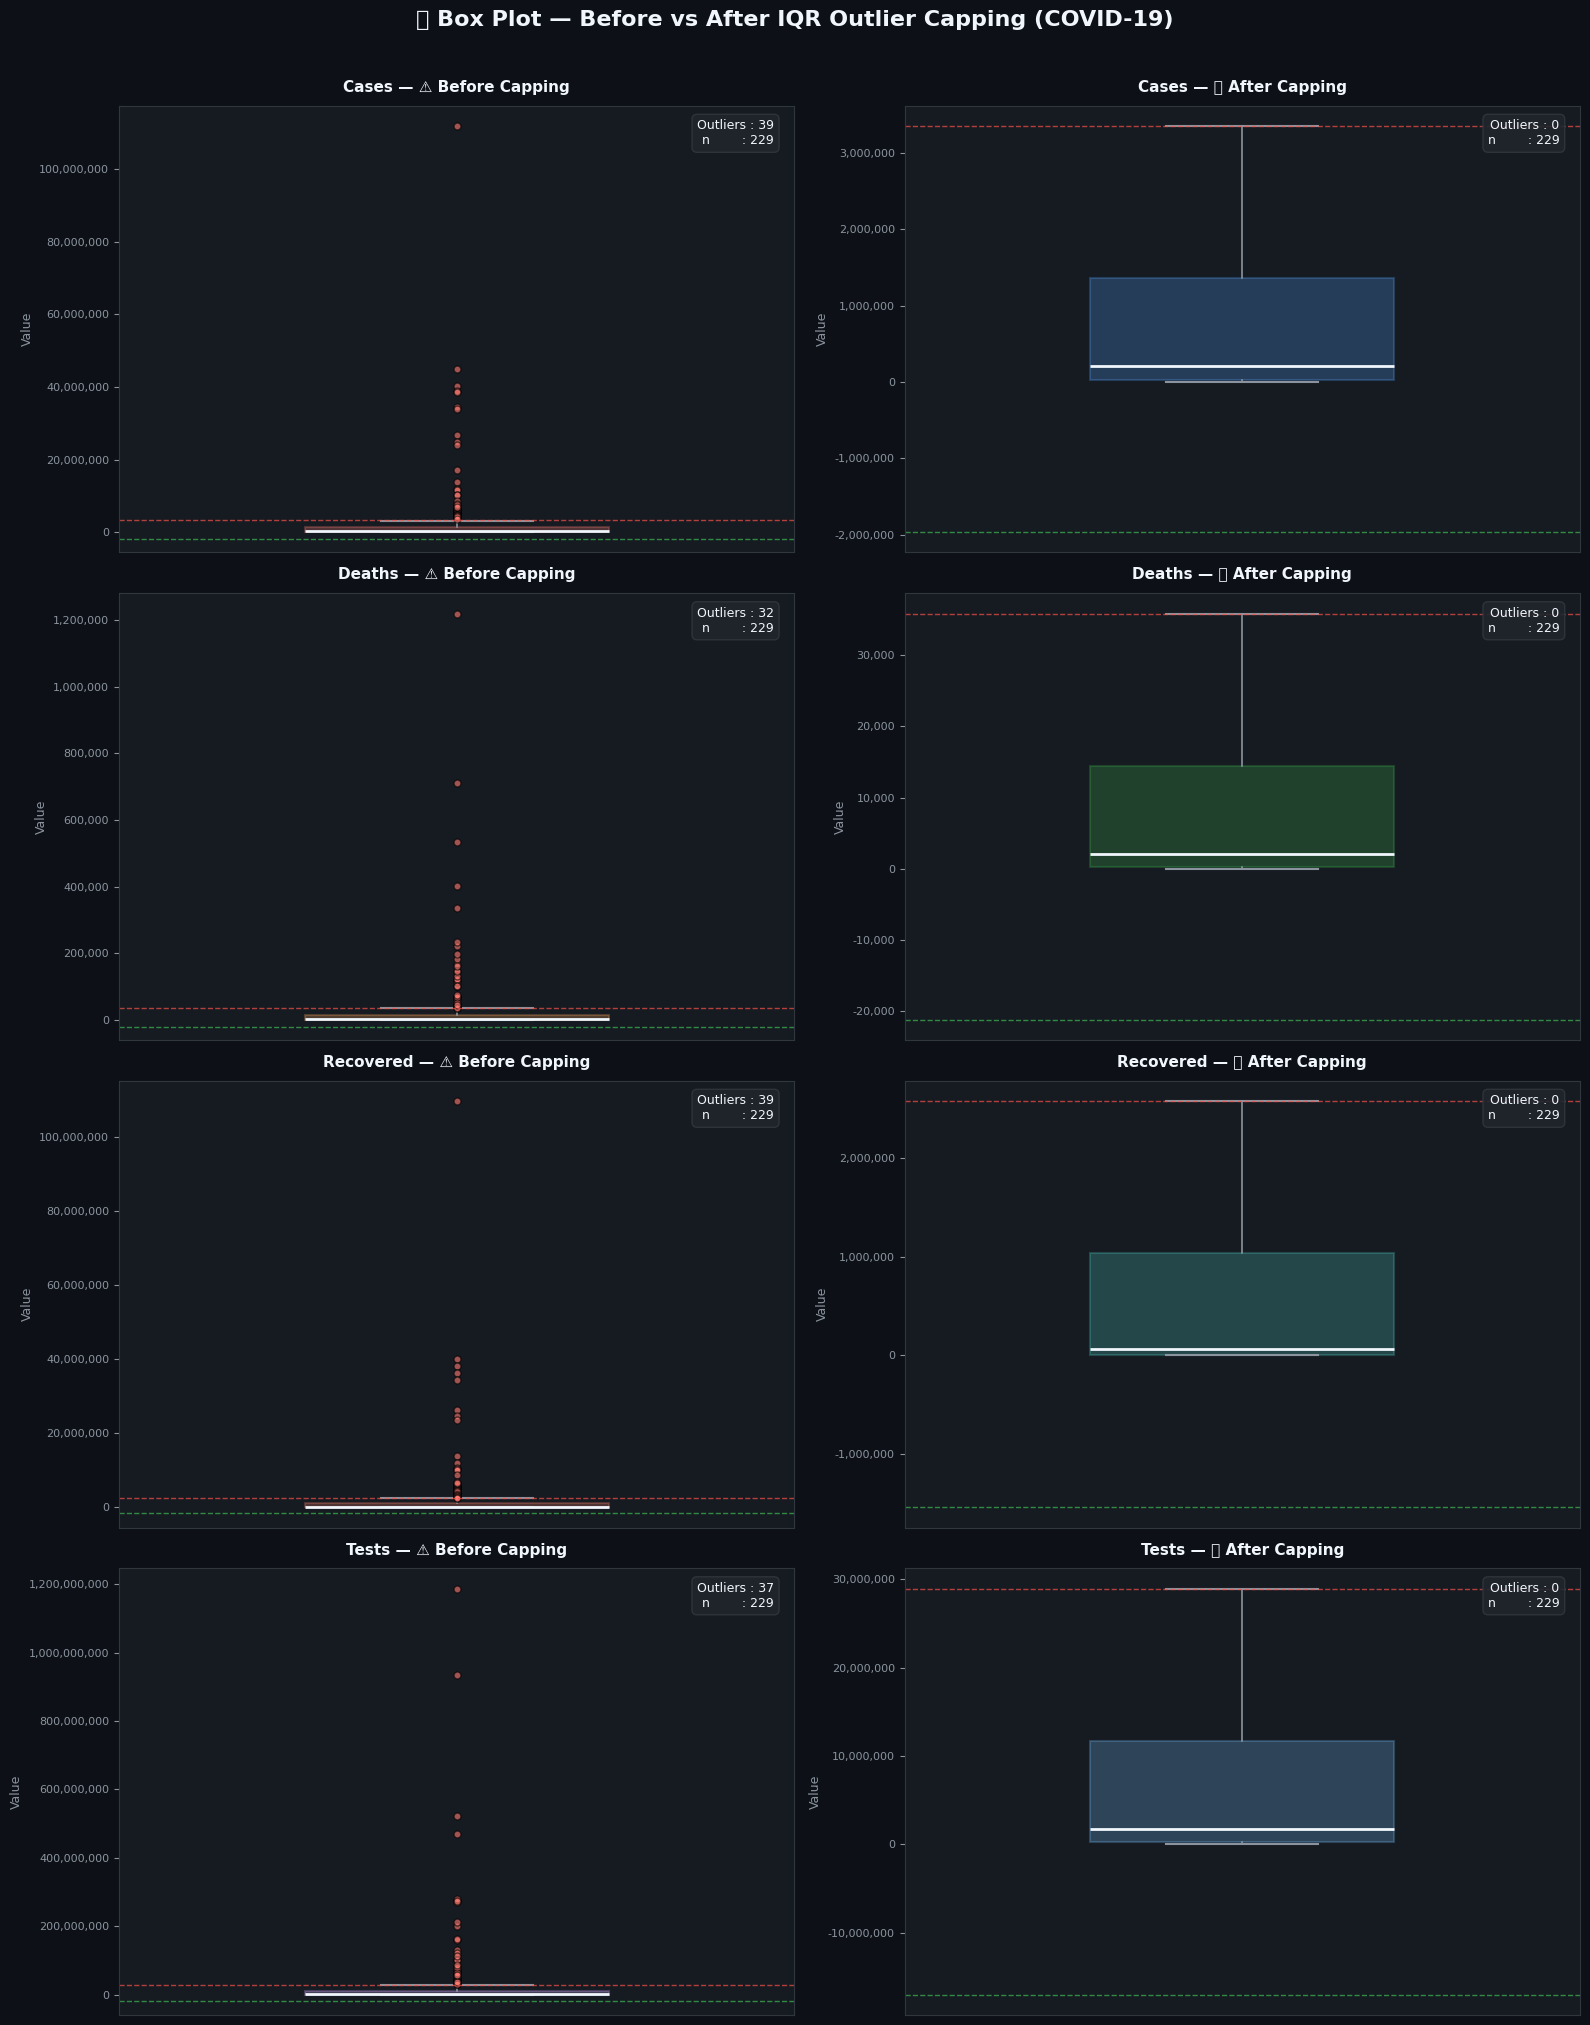


 Outlier Summary — Before vs After IQR Capping (±1.5×IQR):
Column            Before    After   Total  % Before
────────────────────────────────────────────────────
Cases                 39        0     229     17.0%
Deaths                32        0     229     14.0%
Recovered             39        0     229     17.0%
Tests                 37        0     229     16.2%


In [23]:


# ── Columns with their capped versions ───────────────────────────────────────
cols = ['Cases', 'Deaths', 'Recovered', 'Tests']

# ── IQR-based outlier counter ─────────────────────────────────────────────────
def count_outliers(series):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return ((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum()

# ── Plot setup ────────────────────────────────────────────────────────────────
n_cols_grid = 2   # before | after per row
n_rows = len(cols)

fig, axes = plt.subplots(n_rows, n_cols_grid,
                          figsize=(16, 5 * n_rows),
                          facecolor='#0d1117')

palette_before = ['#ff7b72', '#ffa657', '#f78166', '#d2a8ff']
palette_after  = ['#58a6ff', '#3fb950', '#4ECDC4', '#79c0ff']

def draw_box(ax, data, color, col_label, is_capped):
    ax.set_facecolor('#161b22')

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    lower_fence = Q1 - 1.5 * IQR
    n_outliers = count_outliers(data)

    bp = ax.boxplot(data.dropna(),
                    patch_artist=True,
                    vert=True,
                    widths=0.45,
                    showfliers=True,
                    flierprops=dict(marker='o', color='#ff7b72',
                                    markerfacecolor='#ff7b72',
                                    markersize=5, alpha=0.6, linestyle='none'),
                    medianprops=dict(color='#f0f6fc', linewidth=2),
                    whiskerprops=dict(color='#8b949e', linewidth=1.2),
                    capprops=dict(color='#8b949e', linewidth=1.5),
                    boxprops=dict(color=color, linewidth=1.5))

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.25)

    # IQR fence lines
    ax.axhline(upper_fence, color='#f85149', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(lower_fence, color='#3fb950', linestyle='--', linewidth=1, alpha=0.7)

    label = f'{col_label} — {"✅ After Capping" if is_capped else "⚠️ Before Capping"}'
    ax.set_title(label, color='#f0f6fc', fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('Value', color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    # Annotation box
    ax.text(0.97, 0.97,
            f'Outliers : {n_outliers}\nn        : {len(data.dropna())}',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#f0f6fc',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#21262d',
                      edgecolor='#30363d', alpha=0.9))

# ── Draw all plots ────────────────────────────────────────────────────────────
for i, col in enumerate(cols):
    draw_box(axes[i][0], df[col],              palette_before[i], col, is_capped=False)
    draw_box(axes[i][1], df[col + '_capped'],  palette_after[i],  col, is_capped=True)

fig.suptitle('📦 Box Plot — Before vs After IQR Outlier Capping (COVID-19)',
             color='#f0f6fc', fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n Outlier Summary — Before vs After IQR Capping (±1.5×IQR):")
print(f"{'Column':<15} {'Before':>8} {'After':>8} {'Total':>7} {'% Before':>9}")
print("─" * 52)
for col in cols:
    data_raw    = df[col].dropna()
    data_capped = df[col + '_capped'].dropna()
    n_before = count_outliers(data_raw)
    n_after  = count_outliers(data_capped)
    pct = (n_before / len(data_raw) * 100) if len(data_raw) > 0 else 0
    print(f"{col:<15} {n_before:>8} {n_after:>8} {len(data_raw):>7} {pct:>8.1f}%")


In [24]:
df_capped_iqr = df.copy()
for col in ['Cases', 'Deaths', 'Recovered', 'Tests']:
    df_capped_iqr[col] = df_capped_iqr[col + '_capped']
    df_capped_iqr.drop(columns=[col + '_capped'], inplace=True)

df_capped_iqr.head(2)

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,0.0,0.0
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,0.0,8632.0


In [25]:
# ============================================================
# SECTION 1: FULL EDA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import skew, kurtosis

# Work from df_capped_iqr
df_eda = df_capped_iqr.copy()
numeric_cols = ['population', 'Cases', 'Recovered', 'Deaths', 'Tests']


In [26]:
# ── 1.1 Basic Stats ───────────────────────────────────────────
print("Shape:", df_eda.shape)
print("\nDescriptive Statistics:")
df_eda[numeric_cols].describe().round(2)


Shape: (229, 9)

Descriptive Statistics:


,population,Cases,Recovered,Deaths,Tests
count,2.290000e+02,229.00,229.00,229.00,229.00
mean,3.469404e+07,934906.24,652741.03,9414.77,7823795.49
std,1.386374e+08,1258293.68,975830.57,12931.33,10815508.89
min,7.990000e+02,10.00,0.00,0.00,0.00
25%,4.454310e+05,27334.00,2703.00,189.00,230960.00
50%,5.797805e+06,209906.00,61564.00,2024.00,1751774.00
75%,2.210284e+07,1356546.00,1034145.00,14452.00,11711514.00
max,1.448471e+09,3350364.00,2581308.00,35846.50,28932345.00


In [27]:
# ── 1.2 Skewness & Kurtosis ───────────────────────────────────
print(f"{'Column':<15} {'Skewness':>10} {'Kurtosis':>10}")
print("─" * 38)
for col in numeric_cols:
    s = skew(df_eda[col].dropna())
    k = kurtosis(df_eda[col].dropna())
    print(f"{col:<15} {s:>10.2f} {k:>10.2f}")


Column            Skewness   Kurtosis
──────────────────────────────────────
population            9.03      87.08
Cases                 1.14      -0.36
Recovered             1.24      -0.16
Deaths                1.22      -0.12
Tests                 1.19      -0.27


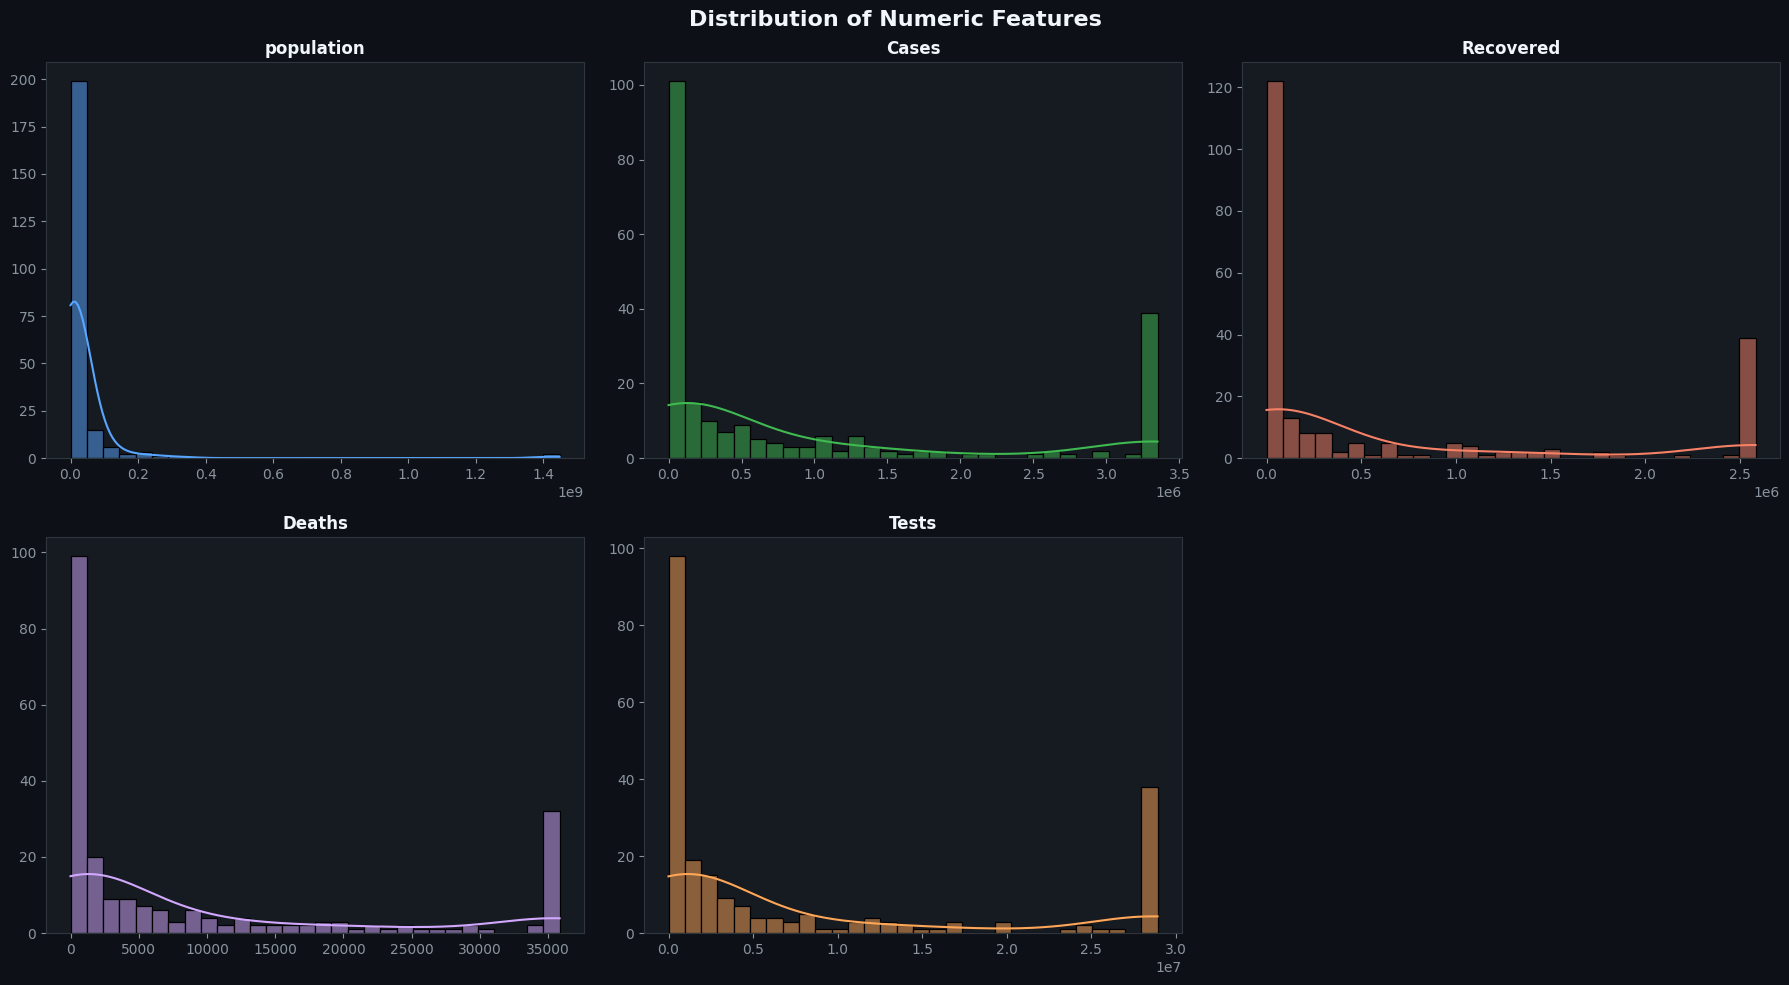

In [28]:
# ── 1.3 Distribution Plots ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#0d1117')
axes = axes.flatten()
colors = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657']

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.set_facecolor('#161b22')
    sns.histplot(df_eda[col].dropna(), kde=True, ax=ax, color=colors[i], bins=30)
    ax.set_title(col, color='#f0f6fc', fontweight='bold')
    ax.tick_params(colors='#8b949e')
    ax.set_xlabel(''); ax.set_ylabel('')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

axes[-1].set_visible(False)
fig.suptitle('Distribution of Numeric Features', color='#f0f6fc', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


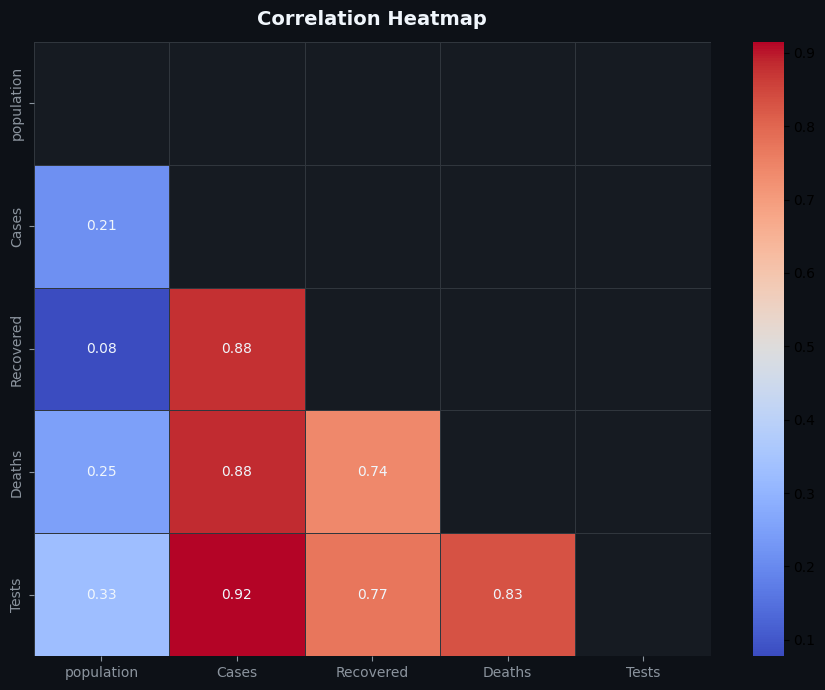

In [29]:
# ── 1.4 Correlation Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#0d1117')
ax.set_facecolor('#161b22')
corr = df_eda[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, linecolor='#30363d',
            annot_kws={'color':'#f0f6fc', 'size':10})
ax.set_title('Correlation Heatmap', color='#f0f6fc', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors='#8b949e')
plt.tight_layout(); plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_17192\3669738974.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cont_data.index, rotation=30, ha='right', color='#8b949e')
C:\Users\User\AppData\Local\Temp\ipykernel_17192\3669738974.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cont_data.index, rotation=30, ha='right', color='#8b949e')


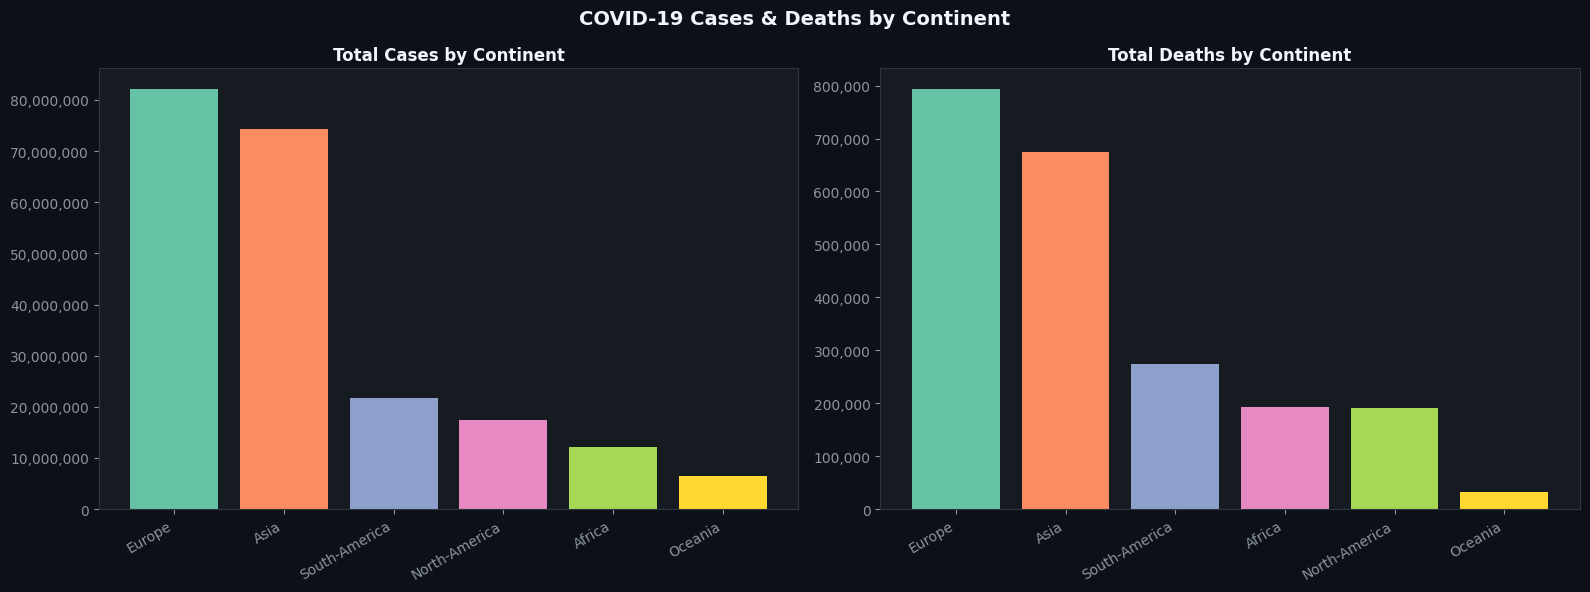

In [30]:
# ── 1.5 Cases & Deaths by Continent ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
palette = sns.color_palette('Set2', 8)

for ax, col in zip(axes, ['Cases', 'Deaths']):
    ax.set_facecolor('#161b22')
    cont_data = df_eda.groupby('continent')[col].sum().sort_values(ascending=False)
    bars = ax.bar(cont_data.index, cont_data.values, color=palette)
    ax.set_title(f'Total {col} by Continent', color='#f0f6fc', fontweight='bold')
    ax.tick_params(colors='#8b949e', axis='both')
    ax.set_xticklabels(cont_data.index, rotation=30, ha='right', color='#8b949e')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

fig.suptitle('COVID-19 Cases & Deaths by Continent', color='#f0f6fc', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


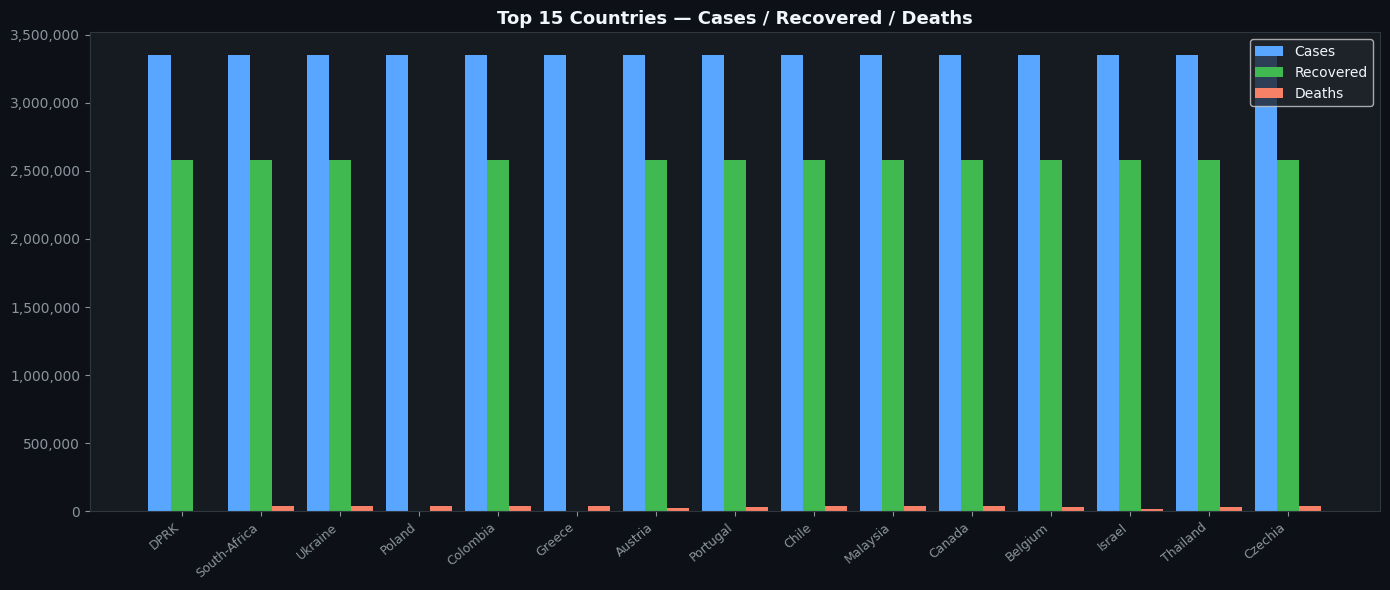

In [31]:
# ── 1.6 Top 15 Countries by Cases ────────────────────────────
top15 = df_eda.nlargest(15, 'Cases')[['country','Cases','Deaths','Recovered']]

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')
x = np.arange(len(top15))
w = 0.28
ax.bar(x - w, top15['Cases'],     w, label='Cases',     color='#58a6ff')
ax.bar(x,      top15['Recovered'],w, label='Recovered', color='#3fb950')
ax.bar(x + w,  top15['Deaths'],   w, label='Deaths',    color='#f78166')
ax.set_xticks(x)
ax.set_xticklabels(top15['country'], rotation=40, ha='right', color='#8b949e', fontsize=9)
ax.tick_params(colors='#8b949e')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(facecolor='#21262d', labelcolor='#f0f6fc')
for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
ax.set_title('Top 15 Countries — Cases / Recovered / Deaths', color='#f0f6fc', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_17192\3484374245.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.index, rotation=30, ha='right', color='#8b949e')
C:\Users\User\AppData\Local\Temp\ipykernel_17192\3484374245.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.index, rotation=30, ha='right', color='#8b949e')


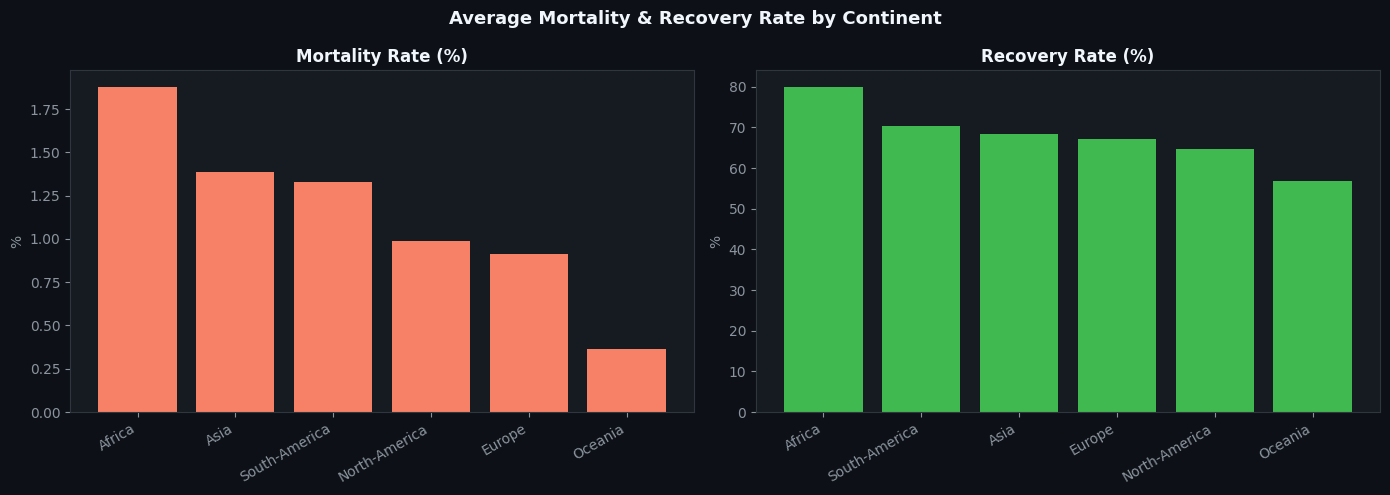

In [32]:
# ── 1.7 Mortality & Recovery Rate by Continent ───────────────
df_eda['mortality_rate'] = df_eda['Deaths']    / df_eda['Cases'].replace(0, np.nan)
df_eda['recovery_rate']  = df_eda['Recovered'] / df_eda['Cases'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
for ax, col, color in zip(axes,
                           ['mortality_rate', 'recovery_rate'],
                           ['#f78166',        '#3fb950']):
    ax.set_facecolor('#161b22')
    data = df_eda.groupby('continent')[col].mean().sort_values(ascending=False)
    ax.bar(data.index, data.values * 100, color=color)
    ax.set_ylabel('%', color='#8b949e')
    ax.set_title(col.replace('_',' ').title() + ' (%)', color='#f0f6fc', fontweight='bold')
    ax.set_xticklabels(data.index, rotation=30, ha='right', color='#8b949e')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

fig.suptitle('Average Mortality & Recovery Rate by Continent', color='#f0f6fc', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


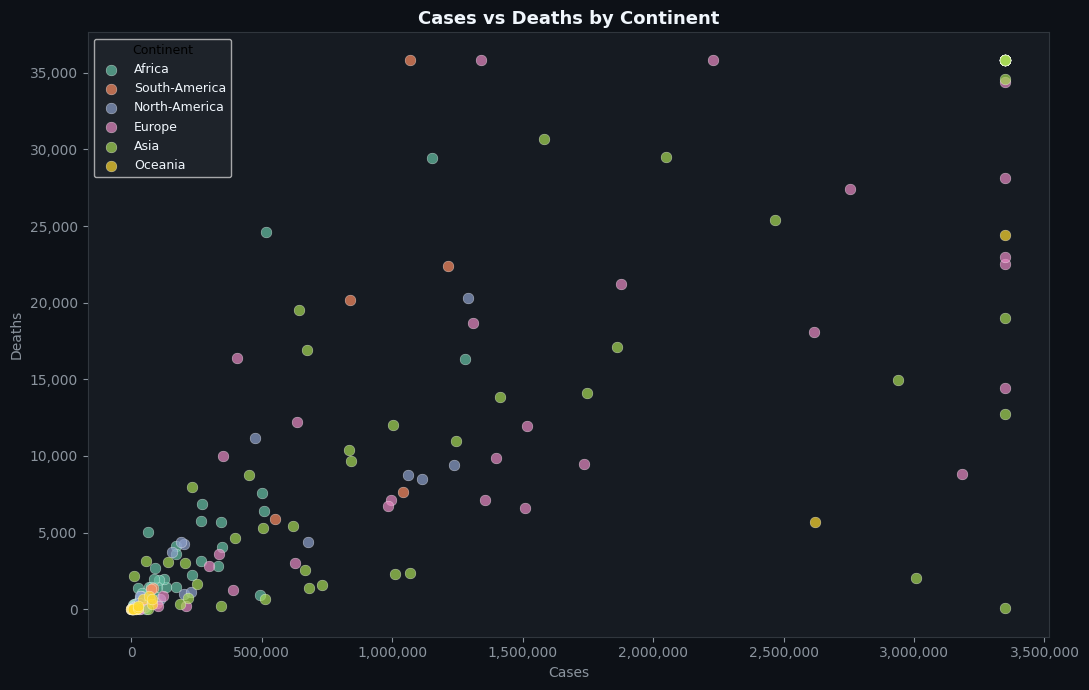

In [33]:
# ── 1.8 Scatter: Cases vs Deaths (coloured by continent) ─────
fig, ax = plt.subplots(figsize=(11, 7), facecolor='#0d1117')
ax.set_facecolor('#161b22')
continents = df_eda['continent'].dropna().unique()
palette = sns.color_palette('Set2', len(continents))

for cont, color in zip(continents, palette):
    sub = df_eda[df_eda['continent'] == cont]
    ax.scatter(sub['Cases'], sub['Deaths'], label=cont,
               color=color, alpha=0.7, edgecolors='white', linewidths=0.3, s=60)

ax.set_xlabel('Cases', color='#8b949e')
ax.set_ylabel('Deaths', color='#8b949e')
ax.tick_params(colors='#8b949e')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(facecolor='#21262d', labelcolor='#f0f6fc', title='Continent',
          title_fontsize=9, fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
ax.set_title('Cases vs Deaths by Continent', color='#f0f6fc', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [34]:
# ============================================================
# SECTION 2: DATA PREPARATION FOR ML
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_ml = df_capped_iqr.copy()

# ── 2.1 Feature Engineering ───────────────────────────────────
pop = df_ml['population'].replace(0, np.nan)
df_ml['cases_per_million']  = (df_ml['Cases']  / pop) * 1_000_000
df_ml['deaths_per_million'] = (df_ml['Deaths'] / pop) * 1_000_000
df_ml['tests_per_million']  = (df_ml['Tests']  / pop) * 1_000_000
df_ml['mortality_rate']     = df_ml['Deaths']    / df_ml['Cases'].replace(0, np.nan)
df_ml['recovery_rate']      = df_ml['Recovered'] / df_ml['Cases'].replace(0, np.nan)
df_ml['test_positivity']    = df_ml['Cases']     / df_ml['Tests'].replace(0, np.nan)

# ── 2.2 Encode Continent ──────────────────────────────────────
le = LabelEncoder()
df_ml['continent_encoded'] = le.fit_transform(df_ml['continent'].fillna('Unknown'))

# ── 2.3 Define Features & Target ─────────────────────────────
# Target: Deaths (regression)
features = [
    'population', 'Cases', 'Recovered', 'Tests',
    'cases_per_million', 'tests_per_million',
    'mortality_rate', 'recovery_rate', 'test_positivity',
    'continent_encoded'
]
target = 'Deaths'

df_ml = df_ml[features + [target]].fillna(0)

X = df_ml[features]
y = df_ml[target]

# ── 2.4 Scale & Split ─────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (183, 10), Test: (46, 10)


In [35]:
# ============================================================
# SECTION 3: ML MODELS
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*45}")
    print(f" Model : {name}")
    print(f" MAE   : {mae:,.2f}")
    print(f" RMSE  : {rmse:,.2f}")
    print(f" R²    : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

models = {
    'Linear Regression'      : LinearRegression(),
    'Ridge Regression'       : Ridge(alpha=1.0),
    'Random Forest'          : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'      : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(evaluate(name, y_test, y_pred))

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n\n Summary Table:")
print(results_df.to_string(index=False))



─────────────────────────────────────────────
 Model : Linear Regression
 MAE   : 3,448.04
 RMSE  : 6,956.84
 R²    : 0.6478

─────────────────────────────────────────────
 Model : Ridge Regression
 MAE   : 3,389.11
 RMSE  : 6,760.37
 R²    : 0.6674

─────────────────────────────────────────────
 Model : Random Forest
 MAE   : 1,508.74
 RMSE  : 3,584.46
 R²    : 0.9065

─────────────────────────────────────────────
 Model : Gradient Boosting
 MAE   : 1,243.64
 RMSE  : 2,497.64
 R²    : 0.9546


 Summary Table:
            Model         MAE        RMSE       R2
Gradient Boosting 1243.641193 2497.638456 0.954603
    Random Forest 1508.738696 3584.455393 0.906499
 Ridge Regression 3389.106827 6760.371433 0.667407
Linear Regression 3448.041676 6956.840587 0.647794


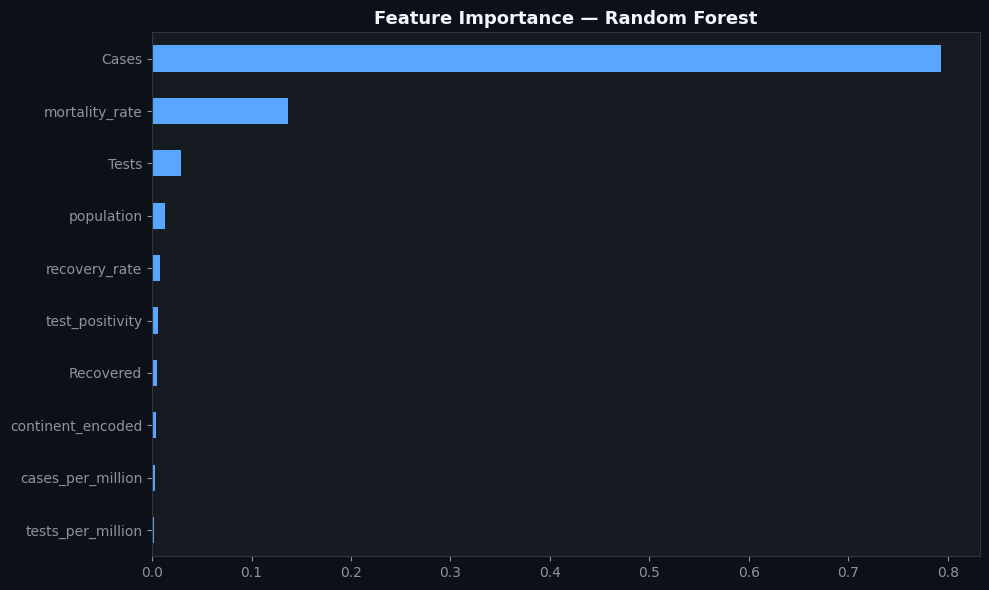

In [36]:
# ── 3.1 Best Model: Feature Importance ────────────────────────
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')
importances.plot(kind='barh', ax=ax, color='#58a6ff')
ax.set_title('Feature Importance — Random Forest', color='#f0f6fc', fontweight='bold', fontsize=13)
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
plt.tight_layout(); plt.show()


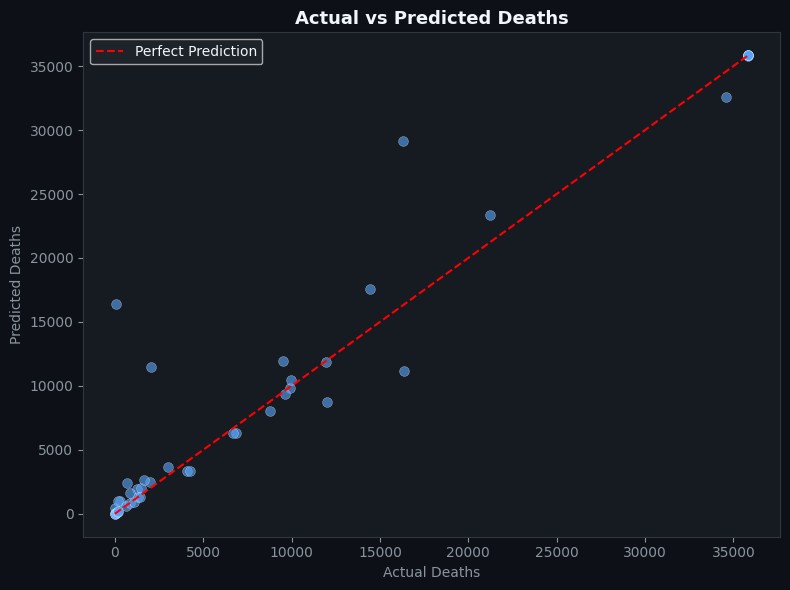

In [37]:
# ── 3.2 Actual vs Predicted Plot ──────────────────────────────
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')
ax.scatter(y_test, y_pred_best, alpha=0.6, color='#58a6ff', edgecolors='white', linewidths=0.3, s=50)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Deaths', color='#8b949e')
ax.set_ylabel('Predicted Deaths', color='#8b949e')
ax.tick_params(colors='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#f0f6fc')
for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
ax.set_title('Actual vs Predicted Deaths', color='#f0f6fc', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [38]:
# Save Gradient Boosting model specifically
gb_model = models['Gradient Boosting']   # already trained above

joblib.dump(gb_model, 'covid_model.pkl')
joblib.dump(scaler,   'covid_scaler.pkl')
joblib.dump(le,       'continent_encoder.pkl')
print("Gradient Boosting model saved.")


Gradient Boosting model saved.
